In [1]:
import os
import requests
import mne
from tqdm import tqdm
import zipfile
import numpy as np
import csv
import torch
import datetime
import pandas as pd
# from torch.utils.data import Dataset, DataLoader, TensorDataset
# import torch.nn as nn
# import torch.nn.functional as F
# from torch import optim
# from torch.optim.lr_scheduler import ReduceLROnPlateau
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Flatten, Dense

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import torchvision.transforms as transforms
from scipy.signal import welch, find_peaks
from scipy.linalg import hankel, eigh
from sklearn.decomposition import FastICA
from sklearn.preprocessing import MinMaxScaler
from PIL import Image
import matplotlib.pyplot as plt
from IPython import display as disp
from scipy.fftpack import fft, ifft
import warnings
from sklearn.cross_decomposition import CCA

from scipy.signal import butter, filtfilt
from scipy.signal import detrend

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using TensorFlow device: {device}")
print('Imports complete.')
print(device)

2025-04-11 09:46:02.946849: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-11 09:46:02.961038: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744361162.978357 1479914 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744361162.983590 1479914 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-11 09:46:03.001848: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Using TensorFlow device: cuda
Imports complete.
cuda


In [10]:
# get the dataset:
if os.path.isdir('EEG_data/EEG_raw'):
    print ("Dataset has already been downloaded...")
else:

    # make directory if it doesn't exist
    directory = 'EEG_data'
    if not os.path.exists(directory):
        os.makedirs(directory)

    # unzipping
    with zipfile.ZipFile('EEG_data/EEG_raw.zip', 'r') as zip_ref:
        zip_ref.extractall(directory)
        print(f"Files unzipped successfully in the '{directory}' directory!")

    # remove the zip file after extraction
    os.remove('EEG_data/EEG_raw.zip')
    print("Zip file removed after extraction.")
        

Files unzipped successfully in the 'EEG_data' directory!
Zip file removed after extraction.


In [4]:
file_path = 'EEG_data/14_20221015_1.cnt'
raw = raw = mne.io.read_raw_cnt(file_path, preload=True)

# Convert raw EEG data to a Pandas DataFrame
df = pd.DataFrame(raw.get_data().T, columns=raw.ch_names)
# Add time column
df['time'] = raw.times

print(df.head())

Reading 0 ... 4411039  =      0.000 ...  4411.039 secs...


/tmp/ipykernel_915154/2537869093.py:2: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = raw = mne.io.read_raw_cnt(file_path, preload=True)


            FP1       FPZ       FP2       AF3       AF4        F7        F5  \
0 -1.758337e-06 -0.000010 -0.000075  0.000002 -0.000019  0.000037  0.000016   
1 -9.238720e-07 -0.000010 -0.000074  0.000003 -0.000017  0.000038  0.000017   
2 -5.960464e-07 -0.000009 -0.000075  0.000005 -0.000014  0.000039  0.000017   
3 -1.251698e-06 -0.000009 -0.000076  0.000008 -0.000012  0.000040  0.000017   
4 -2.354383e-06 -0.000009 -0.000079  0.000009 -0.000009  0.000041  0.000018   

         F3        F1        FZ  ...       PO8       CB1        O1        OZ  \
0 -0.000009  0.000002 -0.000008  ... -0.000028  0.000017 -0.000070  0.000015   
1 -0.000008  0.000001 -0.000008  ... -0.000028  0.000018 -0.000069  0.000016   
2 -0.000007  0.000002 -0.000007  ... -0.000026  0.000020 -0.000068  0.000018   
3 -0.000007  0.000003 -0.000005  ... -0.000023  0.000023 -0.000067  0.000020   
4 -0.000006  0.000004 -0.000004  ... -0.000020  0.000025 -0.000066  0.000023   

         O2       CB2       HEO       VEO   

CHANNEL SELECTION

In [8]:
selected_channels=["FC5", 'FC1', 'CZ', 'P7', 'PO3', 'O1', 'CP2', 'O2', 'C4', 'F4', 'T8']

32

In [9]:
# Load the Excel file (update the file path if needed)
file_path = "EEG_data/SEED-VII/emotion_label_and_stimuli_order.xlsx"
df = pd.read_excel(file_path, header=None)

# Print the first few rows to understand the structure
print(df.head())

            0      1        2        3        4         5         6        7   \
0  Video index      1        2        3        4         5         6        7   
1    Session 1  Happy  Neutral  Disgust      Sad     Anger     Anger      Sad   
2  Video index     21       22       23       24        25        26       27   
3    Session 2  Anger      Sad     Fear  Neutral  Surprise  Surprise  Neutral   
4  Video index     41       42       43       44        45        46       47   

        8        9   ...     11       12       13       14        15  \
0        8        9  ...     11       12       13       14        15   
1  Disgust  Neutral  ...  Happy  Neutral  Disgust      Sad     Anger   
2       28       29  ...     31       32       33       34        35   
3     Fear      Sad  ...  Anger      Sad     Fear  Neutral  Surprise   
4       48       49  ...     51       52       53       54        55   

         16       17       18       19     20  
0        16       17       18   

In [10]:
# Create an empty dictionary for labels
labels_dict = {}

# Iterate over the DataFrame
for i in range(1, df.shape[0], 2):  # Skip every other row since odd rows contain labels
    session_labels = df.iloc[i, 1:].values  # Ignore the first column (session name)
    video_indices = df.iloc[i - 1, 1:].values  # Get video indices

    # Assign each video index its corresponding emotion label
    for vid_idx, label in zip(video_indices, session_labels):
        labels_dict[int(vid_idx)] = label  # Convert video index to integer

# Print the dictionary to verify
print(labels_dict)


{1: 'Happy', 2: 'Neutral', 3: 'Disgust', 4: 'Sad', 5: 'Anger', 6: 'Anger', 7: 'Sad', 8: 'Disgust', 9: 'Neutral', 10: 'Happy', 11: 'Happy', 12: 'Neutral', 13: 'Disgust', 14: 'Sad', 15: 'Anger', 16: 'Anger', 17: 'Sad', 18: 'Disgust', 19: 'Neutral', 20: 'Happy', 21: 'Anger', 22: 'Sad', 23: 'Fear', 24: 'Neutral', 25: 'Surprise', 26: 'Surprise', 27: 'Neutral', 28: 'Fear', 29: 'Sad', 30: 'Anger', 31: 'Anger', 32: 'Sad', 33: 'Fear', 34: 'Neutral', 35: 'Surprise', 36: 'Surprise', 37: 'Neutral', 38: 'Fear', 39: 'Sad', 40: 'Anger', 41: 'Happy', 42: 'Surprise', 43: 'Disgust', 44: 'Fear', 45: 'Anger', 46: 'Anger', 47: 'Fear', 48: 'Disgust', 49: 'Surprise', 50: 'Happy', 51: 'Happy', 52: 'Surprise', 53: 'Disgust', 54: 'Fear', 55: 'Anger', 56: 'Anger', 57: 'Fear', 58: 'Disgust', 59: 'Surprise', 60: 'Happy', 61: 'Disgust', 62: 'Sad', 63: 'Fear', 64: 'Surprise', 65: 'Happy', 66: 'Happy', 67: 'Surprise', 68: 'Fear', 69: 'Sad', 70: 'Disgust', 71: 'Disgust', 72: 'Sad', 73: 'Fear', 74: 'Surprise', 75: 'Hap

In [11]:
def get_montage(montage_file_path: str = 'channel_62_pos.locs') -> mne.channels.DigMontage:
    """Return the montage specified by the param montage_file_path"""
    montage = mne.channels.read_custom_montage(montage_file_path)
    return montage


# Parameters
montage_file_path = 'channel_62_pos.locs'
sfreq = 200  # resample frequency
l_freq = 0.1
h_freq = 70
freqs = 50
subjects_to_process = ['1','2','3','4','5','6','7','9','10']

# Main function to process data
if __name__ == '__main__':
    data_path = 'EEG_data'
    output_path = 'Processed_EEG'
    csv_folder_path = 'EEG_data/save_info'
    raw_files = [f for f in os.listdir(data_path) if f.endswith('.cnt')]
    file_dict = {}
    
    # Organize files by subject
    for file in raw_files:
        subject_id = file[:-15]
        if subject_id in subjects_to_process:  # Only process subject 15
            file_dict.setdefault(subject_id, []).append(file)
    
     # Read the CSV files into a dictionary for ratings based on session and emotion
    ratings_dict = {}
    for csv_file in os.listdir(csv_folder_path):
        if csv_file.endswith('_save_info.csv'):
            subject_id = csv_file.split('_')[0]
            session_id = int(csv_file.split('_')[2])  # Extract session ID from the filename
#             print(f'subject id : {subject_id} session id: {session_id}')
            csv_path = os.path.join(csv_folder_path, csv_file)
            ratings_df = pd.read_csv(csv_path, header=None, names=["task", "video_path", "rating"])

            # Extract video emotions and ratings into a dictionary
            for i, row in ratings_df.iterrows():
                video_path = row['video_path']
                emotion = video_path.split('\\')[-2]  # Get the emotion from the video path
#                 print(f"session id: {session_id}, i: {i}, csv_file: {csv_file}")
                video_index = (session_id-1) * 20 + i + 1 
#                 if i == 0:
#                     print("There is a 0")
                ratings_dict[(subject_id, emotion, video_index)] = row['rating']
#             print(ratings_dict)
            

    # Process each subject
    for key, value in file_dict.items():
        EEG_preprocessed = []  # A list to store data for each video
        
        for raw_file in value:
            print(f'Processing file: {raw_file}')
            raw_path = os.path.join(data_path, raw_file)
            raw = mne.io.read_raw_cnt(raw_path, eog=['HEO', 'VEO'], ecg=['ECG'])

            # Drop unnecessary channels and set montage
            raw.drop_channels(['M1', 'M2', 'ECG', 'HEO', 'VEO'])
            raw.pick_channels(selected_channels)
            
            montage = get_montage(montage_file_path)
            raw.set_montage(montage)
            raw.load_data()

            # Preprocessing: filtering and resampling
            raw.filter(l_freq=l_freq, h_freq=h_freq)
            raw.notch_filter(freqs=freqs)
            raw.resample(sfreq=sfreq, n_jobs=4)

            # Get triggers for each trial
            trigger, _ = mne.events_from_annotations(raw)
            data, _ = raw.get_data(units='uV', return_times=True)
            t = trigger[:, 0]

            # Adjust trigger timing for certain files
            if raw_file == "14_20221015_1.cnt":
                t = []
                start = datetime.datetime.strptime('14:25:34', '%H:%M:%S')
                with open('EEG_data/save_info/14_20221015_1_trigger_info.csv') as f:
                    trigger_data = csv.reader(f)
                    for row in trigger_data:
                        end = datetime.datetime.strptime(row[1].split(' ')[-1], '%H:%M:%S.%f')
                        time_diff = end.timestamp() - start.timestamp()
                        t.append(int(round(time_diff * sfreq)))
            elif raw_file == "9_20221111_3.cnt":
                t = []
                start = datetime.datetime.strptime('14:01:27', '%H:%M:%S')
                with open('EEG_data/save_info/9_20221111_3_trigger_info.csv') as f:
                    trigger_data = csv.reader(f)
                    for row in trigger_data:
                        end = datetime.datetime.strptime(row[1].split(' ')[-1], '%H:%M:%S.%f')
                        time_diff = end.timestamp() - start.timestamp()
                        t.append(int(round(time_diff * sfreq)))

            session_idx = int(raw_file[-5]) - 1
            print(session_idx)
            for i in range(20):
                preprocessed_clip = data[:, t[2 * i]:t[2 * i + 1]]
                num = preprocessed_clip.shape[1] // sfreq
                video_index = session_idx * 20 + i + 1
#                 print(f'video index {video_index}')
                label = labels_dict.get(video_index, "Unknown")  # Get the label
                emotion = label.lower()
                
            
                # Debug print
                print(f'Checking assignment: Subject {key}, Video {video_index}, Label {label}, Shape {preprocessed_clip.shape}')
                 # Retrieve rating for this video using the session_id, emotion, and video_index
                rating = ratings_dict.get((key, emotion, video_index), None)  # Default to None if not found
                if rating is not None and rating>=0.5:
                    # Save data as a dictionary with keys 'data', 'label', and 'rating'
                    EEG_preprocessed.append({
                        'video_index': video_index,  # Store the video index
                        'data': preprocessed_clip[:, :num * 200],
                        'label': label,  # Replace with the actual label logic if needed
                        'rating': rating
                    })
                    print(f'Subject {key}, video {video_index}, label {label}, rating {rating}, shape {preprocessed_clip.shape}')
                elif rating <0.5:
                    print(f"Rating is too small for video {video_index},label {label}, rating {rating}")
                else:
                    print(f"Rating not found for video {video_index} with emotion {emotion}")
#                 # Save data as a dictionary with keys 'data' and 'label'
#                 EEG_preprocessed.append({'data': preprocessed_clip[:, :num * 200], 'label': label})
#                 print(f'Subject {key}, video {video_index}, label {label}, shape {preprocessed_clip.shape}')
#         print("Final EEG_preprocessed sample:")
#         print(EEG_preprocessed[:3])  # Print first 3 entries
        # Save the EEG data for each subject in the desired output format
        if not os.path.exists(output_path):
            os.makedirs(output_path)
        
        np.save(os.path.join(output_path, f"subject_{key}.npy"), EEG_preprocessed)

        

Processing file: 3_20221016_3.cnt
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Reading 0 ... 3578679  =      0.000 ...  3578.679 secs...


/tmp/ipykernel_3094219/2087854502.py:64: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  raw = mne.io.read_raw_cnt(raw_path, eog=['HEO', 'VEO'], ecg=['ECG'])
[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Used Annotations descriptions: ['1', '2']
2
Checking assignment: Subject 3, Video 41, Label Happy, Shape (11, 26890)
Subject 3, video 41, label Happy, rating 0.6, shape (11, 26890)
Checking assignment: Subject 3, Video 42, Label Surprise, Shape (11, 32815)
Rating is too small for video 42,label Surprise, rating 0.3
Checking assignment: Subject 3, Video 43, Label Disgust, Shape (11, 29852)
Subject 3, video 43, label Disgust, rating 0.6, shape (11, 29852)
Checking assignment: Subject 3, Video 44, Label Fear, Shape (11, 13976)
Rating is too small for video 44,label Fear, rating 0.4
Checking assignment: Subject 3, Video 45, Label Anger, Shape (11, 41725)
Subject 3, video 45, label Anger, rating 0.7999999999999999, shape (11, 41725)
Checking assignment: Subject 3, Video 46, Label Anger, Shape (11, 15357)
Subject 3, video 46, label Anger, rating 0.7, shape (11, 15357)
Checking assignment: Subject 3, Video 47, Label Fear, Shape (11, 19517)
Subject 3, video 47, label Fear, rating 0.6, shape (1

[Parallel(n_jobs=4)]: Done  11 out of  11 | elapsed:    3.8s finished


Reading 0 ... 4462919  =      0.000 ...  4462.919 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 70.00 Hz
- Upper transition bandwidth: 17.50 Hz (-6 dB cutoff frequency: 78.75 Hz)
- Filter length: 33001 samples (33.001 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0

...

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.1 - 70 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Upper passband edge: 70.00 Hz
- Upper transition bandwidth: 17.50 Hz (-6 dB cutoff frequency: 78.75 Hz)
- Filter length: 33001 samples (33.001 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Used Annotations descriptions: ['1', '2']


[Parallel(n_jobs=4)]: Done  11 out of  11 | elapsed:    5.3s finished


0
Checking assignment: Subject 1, Video 1, Label Happy, Shape (11, 12394)
Rating is too small for video 1,label Happy, rating 0.3
Checking assignment: Subject 1, Video 2, Label Neutral, Shape (11, 44408)
Rating is too small for video 2,label Neutral, rating 0.1
Checking assignment: Subject 1, Video 3, Label Disgust, Shape (11, 37916)
Subject 1, video 3, label Disgust, rating 0.6, shape (11, 37916)
Checking assignment: Subject 1, Video 4, Label Sad, Shape (11, 45954)
Rating is too small for video 4,label Sad, rating 0.1
Checking assignment: Subject 1, Video 5, Label Anger, Shape (11, 53226)
Subject 1, video 5, label Anger, rating 0.6, shape (11, 53226)
Checking assignment: Subject 1, Video 6, Label Anger, Shape (11, 43895)
Subject 1, video 6, label Anger, rating 0.5, shape (11, 43895)
Checking assignment: Subject 1, Video 7, Label Sad, Shape (11, 52990)
Rating is too small for video 7,label Sad, rating 0.2
Checking assignment: Subject 1, Video 8, Label Disgust, Shape (11, 30049)
Subject

In [7]:
def compute_snr(clean_signal, noisy_signal):
    """
    Computes the Signal-to-Noise Ratio (SNR) in dB.
    
    Parameters:
    clean_signal (numpy.ndarray): Original clean EEG signal (T,)
    noisy_signal (numpy.ndarray): EEG signal with added noise (T,)
    
    Returns:
    float: SNR in decibels (dB)
    """
    signal_power = np.mean(clean_signal**2)
    noise_power = np.mean((noisy_signal - clean_signal)**2)
    
    if noise_power == 0:
        return np.inf  # Avoid division by zero
    
    snr_db = 10 * np.log10(signal_power / noise_power)
    return snr_db

In [8]:
def remove_baseline_drift(signal, order=3):
    """
    Removes baseline drift using polynomial curve fitting.
    
    Parameters:
        signal (numpy array): The input EEG or fNIRS signal.
        order (int): The polynomial order for baseline fitting (default: 3).
    
    Returns:
        corrected_signal (numpy array): The detrended signal.
        baseline (numpy array): The estimated baseline.
    """
    t = np.arange(len(signal))  # Time indices
    coeffs = np.polyfit(t, signal, order)  # Fit polynomial of given order
    baseline = np.polyval(coeffs, t)  # Evaluate polynomial baseline
    corrected_signal = signal - baseline  # Subtract baseline

    return corrected_signal, baseline

In [2]:
def filter_extreme_peaks(freqs, psd, threshold=95):
    """ Filter out extreme PSD peaks based on a threshold percentile. """
    cutoff = np.percentile(psd, threshold)  # Get the 95th percentile value
    valid_indices = psd <= cutoff  # Boolean mask for keeping values below the threshold
    
    # Ensure valid_indices is applied correctly
#     print(freqs)
    freqs_filtered = freqs[valid_indices]  # Apply mask to frequencies
    psd_filtered = psd[valid_indices]  # Apply mask to PSD values

    return freqs_filtered, psd_filtered

def initialize_omega_psd(signal, K):
    """
    Initialize omega using the dominant frequencies of the signal,
    with extreme peak filtering.
    """
    freqs, psd = welch(signal, nperseg=len(signal)//8)
    freqs, psd = filter_extreme_peaks(freqs, psd)
    
    # Select top-K dominant frequencies
    dominant_freqs = freqs[np.argsort(psd)[-K:]]
    return np.sort(dominant_freqs)

In [3]:
# Variational Mode Decomposition (VMD)
def VMD(signal, alpha=400, tau=0.5, K=5, DC=0, init=1, tol=1e-6):
    signal = np.asarray(signal)  # Ensure it's a NumPy array
    N = len(signal)
#     print(f'length N: {N}')
    
    # Frequency domain
    freq = np.arange(1, N + 1) / N - 0.5 - (1 / N) * np.mod(N, 2)
    
    # Initialization
    u = np.zeros((K, N))  # Modes
    omega = initialize_omega_psd(signal, K)  # Use filtered peak frequencies
    omega += np.random.uniform(-0.05, 0.05, size=omega.shape)

#     np.linspace(0, 0.5, K)  # Center frequencies
    lambda_hat = np.zeros(N, dtype=complex)  # Lagrange multiplier (complex)
    
    # Transform to Fourier domain
    f_hat = fft(signal)
    
    u_hat = np.zeros((K, N), dtype=complex)
    
    iter_count = 0
    omega_old = np.copy(omega)
#     print("reached loop")
    while True:
        for k in range(K):
            sum_u_hat = np.sum(u_hat, axis=0) - u_hat[k]
            residual = f_hat - sum_u_hat - lambda_hat / 2
            
            # Update u_hat[k]
            u_hat[k] = residual / (1 + alpha * (freq - omega[k]) ** 2)
            
            # Update omega[k]
            omega[k] = np.sum(np.abs(freq) * np.abs(u_hat[k]) ** 2) / np.sum(np.abs(u_hat[k]) ** 2)
#         if iter_count % 10 == 0:
#             print(f"Iteration {iter_count}: omega = {omega}")

        # Update lambda_hat
        lambda_hat += tau * (np.sum(u_hat, axis=0) - f_hat)
#         print(f"lambda_hat: {lambda_hat}")
        # Check convergence
        if np.linalg.norm(omega - omega_old) < tol:
#             print("converged")
            break
        
        omega_old = np.copy(omega)
        iter_count += 1
    
    # Compute final modes
    for k in range(K):
        u[k] = np.real(ifft(u_hat[k]))
    
    return u

# Canonical Correlation Analysis (CCA) for Denoising
def CCA_denoise(modes, num_components=1):
    cca = CCA(n_components=num_components)
    X1, X2 = modes[:-1], modes[1:]
    cca.fit(X1.T, X2.T)
    cleaned_signal = cca.transform(X1.T, X2.T)[0].T
    return cleaned_signal



# Example usage
def process_eeg(signal):
    modes = VMD(signal, K=5)  # Decompose into 4 modes
#     for i, mode in enumerate(modes):
#         print(f"Mode {i}: mean={np.mean(mode)}, std={np.std(mode)}, max={np.max(mode)}, min={np.min(mode)}")
    for i in range(modes.shape[0]):
        modes[i] = (modes[i] - np.mean(modes[i])) / (np.std(modes[i]) + 1e-8)

    clean_signal = CCA_denoise(modes)  # Denoise using CCA
    print(f"Original signal: mean={np.mean(signal)}, std={np.std(signal)}")
#     print(f"Clean signal (before scaling): mean={np.mean(clean_signal)}, std={np.std(clean_signal)}, max={np.max(clean_signal)}, min={np.min(clean_signal)}")
    # Get robust statistics from noisy input
    estimated_mean, estimated_std = robust_stats(signal)


    
    # Scale using the estimated clean signal statistics
    clean_signal = (clean_signal- np.mean(clean_signal)) / (np.std(clean_signal) + 1e-8)
    clean_signal = clean_signal * estimated_std + estimated_mean

    print(f"Final Clean Signal: mean={np.mean(clean_signal)}, std={np.std(clean_signal)}")



    return clean_signal, modes

In [4]:
def robust_stats(signal):
    """Compute robust mean & scale using median and MAD."""
    median = np.median(signal)
    mad = np.median(np.abs(signal - median)) * 1.4826  # Convert MAD to std estimate
    return median, mad

In [5]:
def high_pass_filter(signal, cutoff_freq = 0.2,sampling_rate = 2048, order = 3):
    # https://medium.com/@ChanakaDev/low-pass-high-pass-and-band-pass-filters-with-scipy-python-a87b2332ce25
    

    # Design the high-pass filter (change btype to 'highpass')
    nyq = 0.5 * sampling_rate
    normal_cutoff = cutoff_freq / nyq
    b, a = butter(order, normal_cutoff, btype='highpass', analog=False)

    # Apply the filter
    filtered_data= filtfilt(b, a, signal)
    return filtered_data

In [13]:
# Checking for missing values
for col in df.columns:
    if(df[col].isnull().sum()>0):
        print(col)
# NO missing value

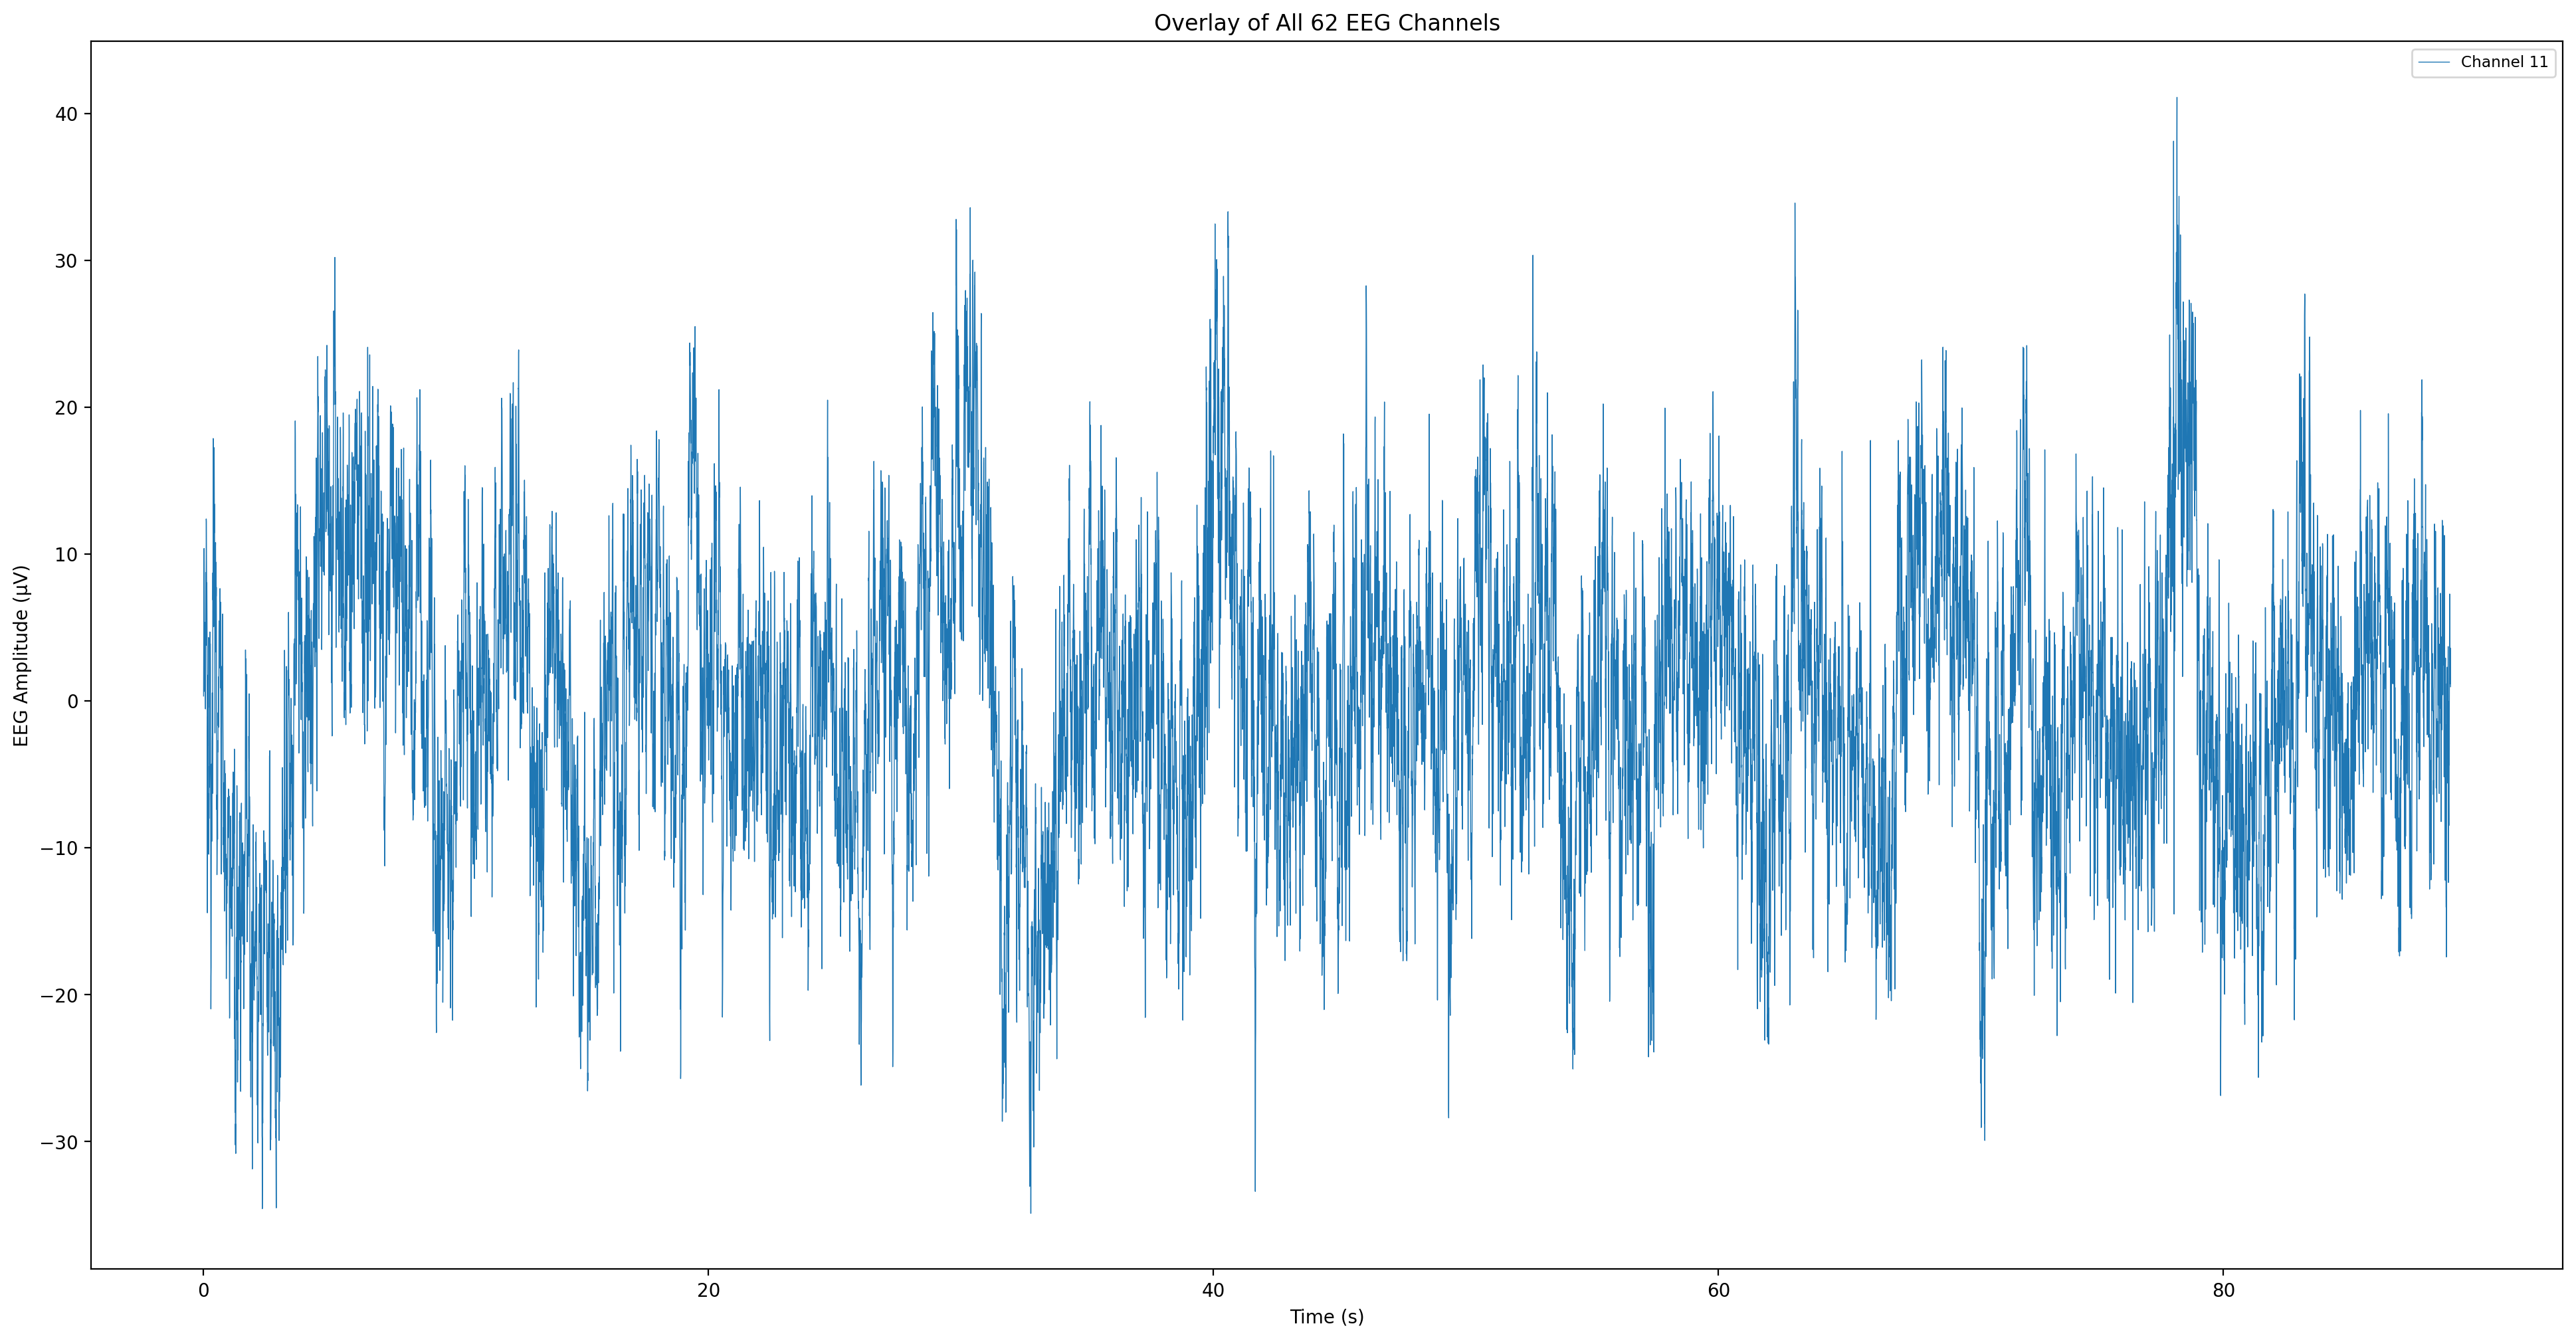

In [22]:
# Load the .npy file
original_eeg_data = np.load("Processed_EEG/subject_20.npy", allow_pickle=True)  # Adjust file path as needed

# Extract time-series data from the first entry (assuming same shape for all)
first_entry = original_eeg_data[79]  # Assuming eeg_data is a list of dicts like {'data': array, 'label': emotion}
original_eeg_signals = first_entry['data']  # Shape: (62, timepoints)

# Create time vector based on sample rate
sfreq = 200  # Hz, adjust if different
time = np.arange(original_eeg_signals.shape[1]) / sfreq  # Convert sample index to seconds

# Plot all 62 channels
plt.figure(figsize=(24, 12), dpi=200)

# for i in range(original_eeg_signals.shape[0]):  # Loop over 62 channels
plt.plot(time, original_eeg_signals[7] , linewidth=0.5, label=f'Channel {i+1}')  
    #   
    # Offset each channel vertically for visibility (scaling factor 50 can be adjusted)

plt.xlabel("Time (s)")
plt.ylabel("EEG Amplitude (µV)")
plt.title("Overlay of All 62 EEG Channels")
plt.legend(loc="upper right", fontsize="small", ncol=4)  # Reduce clutter in the legend
plt.show()

In [10]:
# Define paths
data_dir = "Processed_EEG"
output_dir = "Processed_EEG_Output"  # Save processed files in a new directory
subjects_to_process = ['14']
# 14 gets stuck in trial 16, channel 9???
# List all subject .npy files
subject_files = [f for f in os.listdir(data_dir) if f.endswith(".npy")]


for subject_file in subject_files:
        subject_id = subject_file.split('_')[-1].split('.')[0]
        
        print(subject_id)
        if subject_id in subjects_to_process:
            subject_path = os.path.join(data_dir, subject_file)
            eeg_data = np.load(subject_path, allow_pickle=True)  # Load EEG data

            print(f"Processing {subject_file}...")

            # Process all 80 emotion trials
            for trial_idx, trial in enumerate(eeg_data):  # Each trial is a dictionary {'data': array, 'label': emotion}
                video_index = trial['video_index']
                if video_index == 56:
                    print('skipped 59')
                    continue
                eeg_signals = trial['data']  # Shape: (62, timepoints)

                print(f"Processing Video Index: {video_index}, Trial: {trial_idx+1}")

#                 eeg_signals = trial['data']  # Shape: (62, timepoints)
#                 print(trial)
#                 print(eeg_signals.shape)
                for i in range(eeg_signals.shape[0]):  # Loop over 62 channels
                    eeg_signals[i], _ = process_eeg(eeg_signals[i])  # Apply processing
                    print(f"Subject {subject_file} - Trial {trial_idx+1} - Channel {i+1} completed")

                trial['data'] = eeg_signals  # Update trial with processed signals

            # Save the processed subject file
            output_path = os.path.join(output_dir, subject_file)
            np.save(output_path, eeg_data)

            print(f"Saved processed data for {subject_file} to {output_path}")


2
5
10
17
19
4
3
18
16
11
20
12
15
9
7
14
Processing subject_14.npy...
Processing Video Index: 41, Trial: 1
Original signal: mean=-0.27609666115096465, std=96.59606451365948
Final Clean Signal: mean=-5.077268735728341, std=47.77042028993765
Subject subject_14.npy - Trial 1 - Channel 1 completed
Original signal: mean=-0.24230760501262485, std=31.282262163341336
Final Clean Signal: mean=-2.4087850581426675, std=16.460626581968874
Subject subject_14.npy - Trial 1 - Channel 2 completed
Original signal: mean=0.01574681372761868, std=19.99779805929615
Final Clean Signal: mean=-0.3491875206488878, std=13.372504039019665
Subject subject_14.npy - Trial 1 - Channel 3 completed
Original signal: mean=0.27956681585227067, std=84.0798750313814
Final Clean Signal: mean=1.6049947458750544, std=46.53123891011587
Subject subject_14.npy - Trial 1 - Channel 4 completed
Original signal: mean=0.005411042583122857, std=83.36688836272619
Final Clean Signal: mean=-2.0908905651793708, std=27.62094014991499
Subj

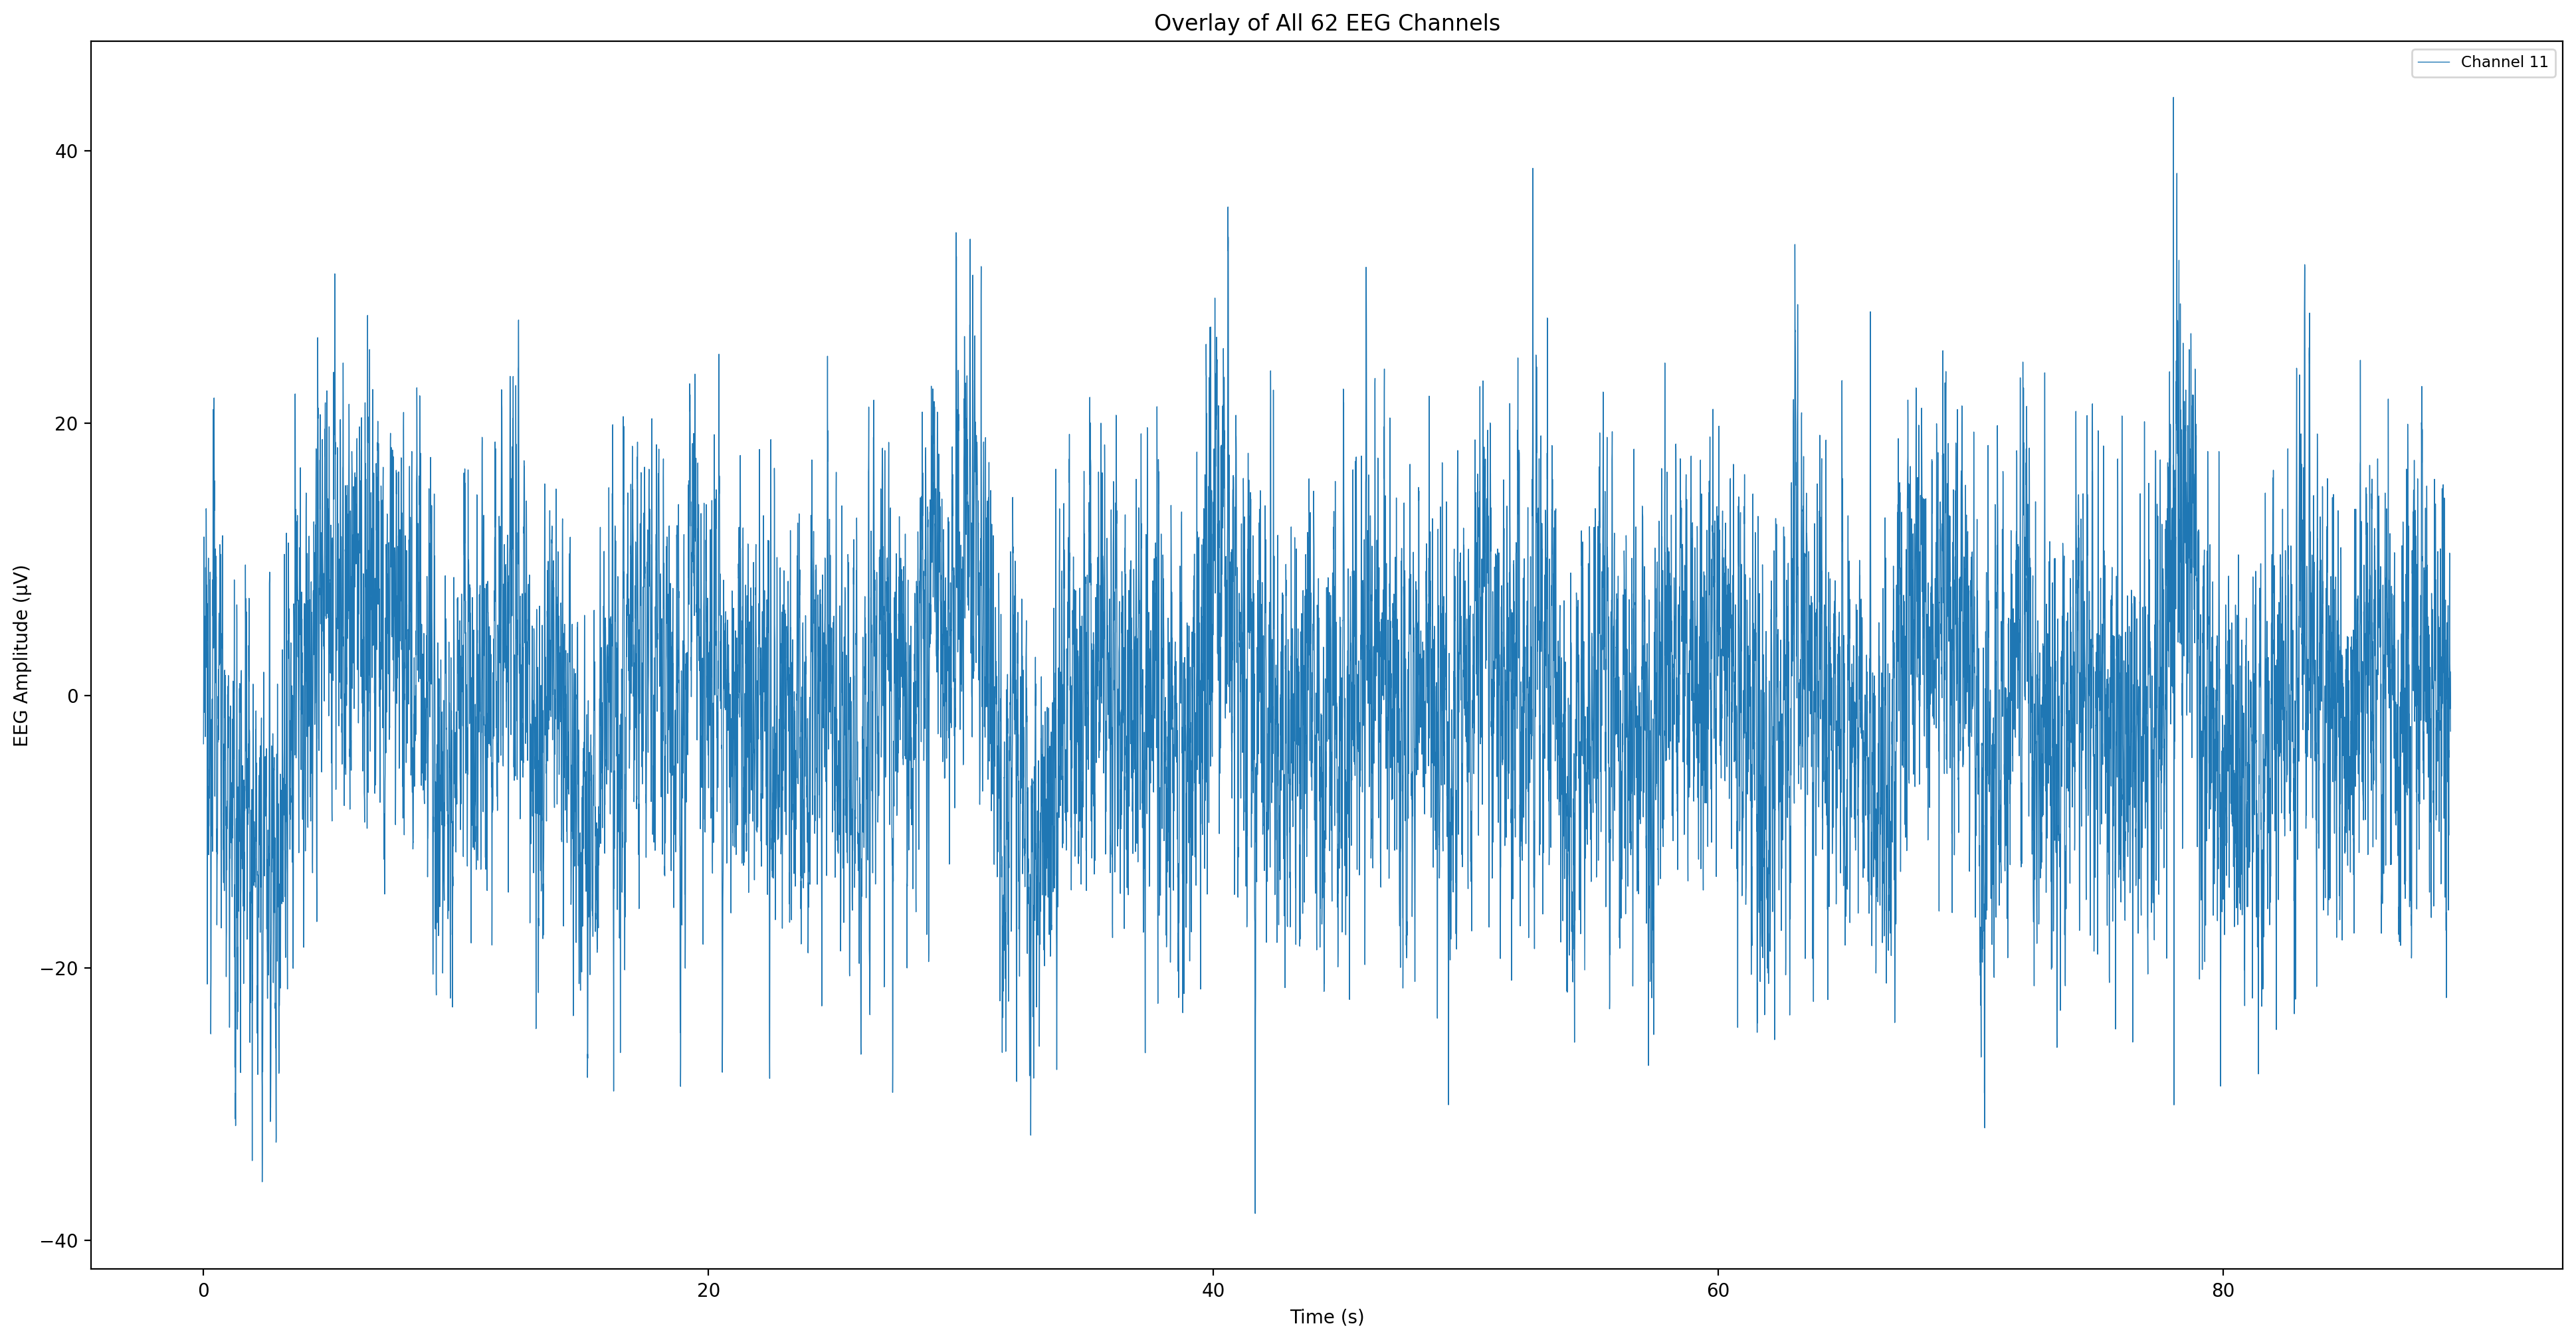

In [21]:

# # Extract time-series data from the first entry (assuming same shape for all)
# first_entry = eeg_data[7]  # Assuming eeg_data is a list of dicts like {'data': array, 'label': emotion}
# eeg_signals = first_entry['data']  # Shape: (62, timepoints)

# Create time vector based on sample rate
sfreq = 200  # Hz, adjust if different
time = np.arange(eeg_signals.shape[1]) / sfreq  # Convert sample index to seconds

# Plot all 62 channels
plt.figure(figsize=(24, 12), dpi=200)

# for i in range(eeg_signals.shape[0]):  # Loop over 62 channels
plt.plot(time, eeg_signals[7] , linewidth=0.5, label=f'Channel {i+1}')  
    #     + i * 50
    # Offset each channel vertically for visibility (scaling factor 50 can be adjusted)

plt.xlabel("Time (s)")
plt.ylabel("EEG Amplitude (µV)")
plt.title("Overlay of All 62 EEG Channels")
plt.legend(loc="upper right", fontsize="small", ncol=4)  # Reduce clutter in the legend
plt.show()